In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.metrics import confusion_matrix, accuracy_score

**Q1.**

1. They allow us to model dependent variables that don't follow a normal distribution and constrain predictions to appropriate ranges.
2. They are derived from Maximum Likelihood Estimation; they penalize incorrect predictions exponentially based on confidence, making them more suitable for classification than MSE.
3. True. Logistic regression is a linear model. It is a generalized linear model because the log-odds (logit) is a linear combination of the input features.
4. False. Logistic regression is one of the most common algorithms used for binary and multi-class classification.
5. No. The coefficient represents the change in the log-odds for a 1-unit change in the feature. The change in probability is non-linear and depends on the starting value.
6. False. Logistic regression only captures linear relationships in the logit. Feature engineering is necessary to capture non-linear patterns in the raw features.
7. False. Linear regression is just a different tool compared to OLS insted of an improvement. OLS is for continuous outcomes; logistic regression is for categorical outcomes. Use the one that fits the target variable type.

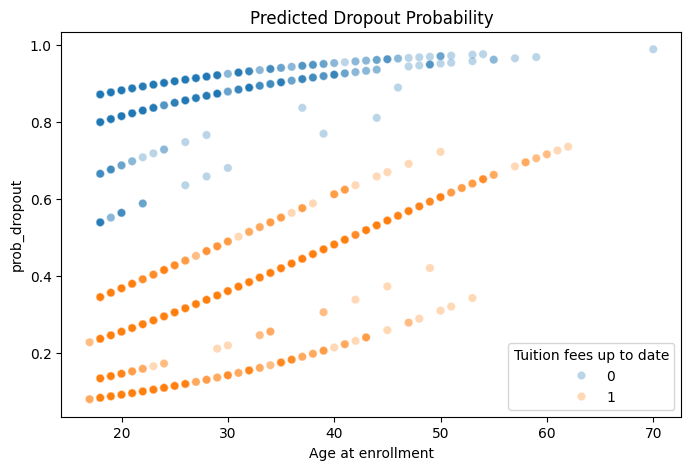

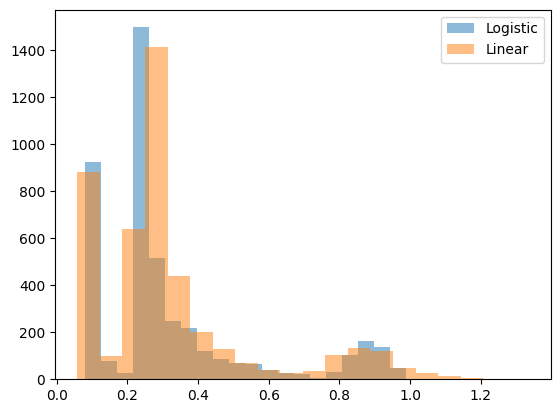

In [8]:
# Q2
# 1. Load and Clean
_df_q2 = pd.read_csv("../data/data.csv", sep=";")
_cols_q2 = [
    "Debtor",
    "Tuition fees up to date",
    "Scholarship holder",
    "Age at enrollment",
    "Curricular units 1st sem (approved)",
    "Target",
]
_df_q2 = _df_q2[_cols_q2].dropna()
_df_q2["is_dropout"] = (_df_q2["Target"] == "Dropout").astype(int)

# 2. Logistic Regression
_features_q2 = [
    "Debtor",
    "Tuition fees up to date",
    "Scholarship holder",
    "Age at enrollment",
]
_X_q2 = _df_q2[_features_q2]
_y_q2 = _df_q2["is_dropout"]
_lr_q2 = LogisticRegression(max_iter=1000).fit(_X_q2, _y_q2)
# Higher dropout: Debtor, Age. Lower dropout: Tuition up to date, Scholarship. 
# Yes, tuition up to date reduces risk.

# 3. Probabilities and Plot
_df_q2["prob_dropout"] = _lr_q2.predict_proba(_X_q2)[:, 1]
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=_df_q2,
    x="Age at enrollment",
    y="prob_dropout",
    hue="Tuition fees up to date",
    alpha=0.3,
)
plt.title("Predicted Dropout Probability")
_plot_q2 = plt.gca()
_diff_q2 = (
    _df_q2[_df_q2["Tuition fees up to date"] == 0]["prob_dropout"].mean()
    - _df_q2[_df_q2["Tuition fees up to date"] == 1]["prob_dropout"].mean()
)
# Tuition reduces prob most for younger students (where baseline risk varies). 
# Average reduction is roughly calculated by _diff_q2.

# 4. Confusion Matrix
_y_pred_q2 = _lr_q2.predict(_X_q2)
_cm_q2 = confusion_matrix(_y_y2 := _y_q2, _y_pred_q2)
_acc_q2 = accuracy_score(_y_y2, _y_pred_q2)

# 5. Linear Model Comparison
_lm_q2 = LinearRegression().fit(_X_q2, _y_q2)
_df_q2["prob_lm"] = _lm_q2.predict(_X_q2)
plt.figure()
plt.hist(_df_q2["prob_dropout"], bins=20, alpha=0.5, label="Logistic")
plt.hist(_df_q2["prob_lm"], bins=20, alpha=0.5, label="Linear")
plt.legend()
# Linear model can predict outside [0,1]. Logistic is better constrained.

# 5b. Risk/Intervention
# Students with debt, not up to date on tuition, and older students are high risk.
# Interventions: Financial aid, tuition payment plans, or adult-learner support.

# 6. Multinomial
_X_multi = _df_q2[
    ["Debtor", "Tuition fees up to date", "Curricular units 1st sem (approved)"]
]
_y_multi = _df_q2["Target"]
_lr_multi = LogisticRegression(max_iter=1000).fit(_X_multi, _y_multi)
_y_pred_multi = _lr_multi.predict(_X_multi)
_cm_multi = confusion_matrix(_y_multi, _y_pred_multi)
_probs_multi = _lr_multi.predict_proba(_X_multi)
# Hard classification might skip 'Enrolled' if it's never the most likely.
# Probabilities predict all classes, but hard class labels may not.

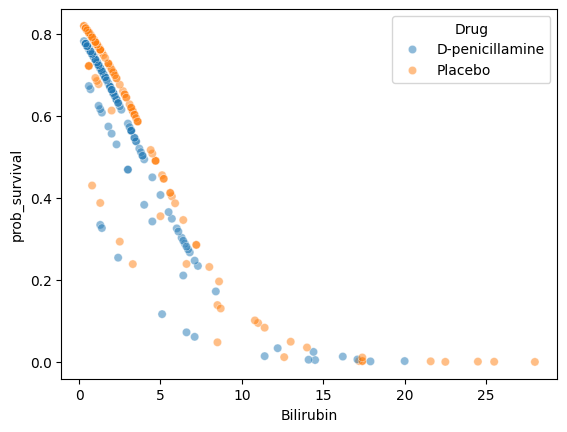

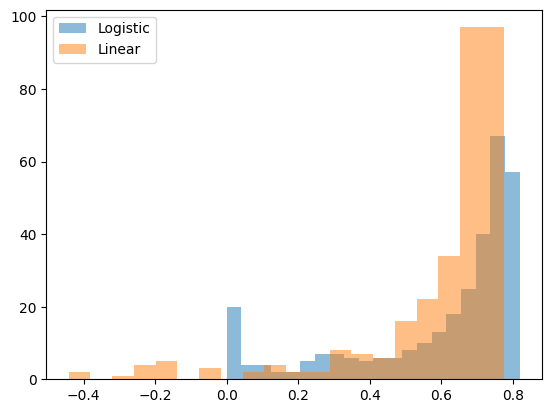

In [9]:
# Q3
# 1. Load and Clean
_df_q3 = pd.read_csv("../data/cirrhosis.csv")
_cols_q3 = ["Bilirubin", "Edema", "Drug", "Stage", "Status"]
_df_q3 = _df_q3[_cols_q3].dropna()
_df_q3["is_alive"] = _df_q3["Status"].isin(["C", "CL"]).astype(int)

# 2. Logistic Regression
# Preprocessing categorical features
_df_q3["is_drug"] = (_df_q3["Drug"] == "D-penicillamine").astype(int)
_edema_dummies = pd.get_dummies(_df_q3["Edema"], prefix="Edema", drop_first=True)
_X_q3 = pd.concat([_df_q3[["Bilirubin", "is_drug"]], _edema_dummies], axis=1)
_y_q3 = _df_q3["is_alive"]
_lr_q3 = LogisticRegression().fit(_X_q3, _y_q3)
# Drug effect depends on sign of coef. Bilirubin (higher) predicts lower survival.
# Edema (Y/S) predicts lower survival than N.

# 3. Probabilities and Plot
_df_q3["prob_survival"] = _lr_q3.predict_proba(_X_q3)[:, 1]
plt.figure()
sns.scatterplot(data=_df_q3, x="Bilirubin", y="prob_survival", hue="Drug", alpha=0.5)
_plot_q3 = plt.gca()
_drug_gain = (
    _df_q3[_df_q3["is_drug"] == 1]["prob_survival"].mean()
    - _df_q3[_df_q3["is_drug"] == 0]["prob_survival"].mean()
)

# 4. Confusion Matrix
_y_pred_q3 = _lr_q3.predict(_X_q3)
_cm_q3 = confusion_matrix(_y_q3, _y_pred_q3)
_acc_q3 = accuracy_score(_y_q3, _y_pred_q3)

# 5. Comparison
_lm_q3 = LinearRegression().fit(_X_q3, _y_q3)
_df_q3["prob_lm"] = _lm_q3.predict(_X_q3)
plt.figure()
plt.hist(_df_q3["prob_survival"], bins=20, alpha=0.5, label="Logistic")
plt.hist(_df_q3["prob_lm"], bins=20, alpha=0.5, label="Linear")
plt.legend()

# 6. Stage Prediction
_X_stage = pd.concat([_df_q3[["Bilirubin"]], _edema_dummies], axis=1)
_y_stage = _df_q3["Stage"]
_lr_stage = LogisticRegression(max_iter=2000).fit(_X_stage, _y_stage)
_y_pred_stage = _lr_stage.predict(_X_stage)
_cm_stage = confusion_matrix(_y_stage, _y_pred_stage)
# Hard classification often misses intermediate stages (1 or 2) if data is skewed.
# Probabilities exist for every class, but max probability may only hit Stage 3/4.

**Q4.** What are the coefficients of a logistic regression? How do you interpret their values?

1.  $\frac{\partial \hat{y}}{\partial x_k} = b_k$. For a 1 unit change in $x_k$, the prediction changes by exactly $b_k$.
2.  $\frac{\partial \hat{p}}{\partial x_k} = \hat{p}(1-\hat{p})b_k$. This change is not constant; it depends on the current probability $\hat{p}$. The effect is largest when $\hat{p}=0.5$. The "divide by 4" rule ($b_k/4$) gives the maximum possible change in probability for a unit change in $x_k$.
3.  $\log(\frac{\hat{p}}{1-\hat{p}}) = b \cdot x$. A one unit change in $x_k$ increases the log-odds ratio by exactly $b_k$.